In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from statsmodels.tsa.holtwinters import ExponentialSmoothing


In [26]:
# Load yearly demand — drop partial years (2002 starts May, 2026 is incomplete)
df = pd.read_csv('./data/Yearly_Market_Demand_2002-2026.csv')
df = df[(df['Year'] >= 2003) & (df['Year'] <= 2025)].copy()
df['Year'] = df['Year'].astype(int)
df['TWh'] = df['Total_Market_Demand'] / 1e6  # MWh → TWh

print(df[['Year', 'TWh']].to_string())


    Year         TWh
1   2003  157.982144
2   2004  162.925342
3   2005  167.153184
4   2006  162.442513
5   2007  164.491422
6   2008  170.876581
7   2009  154.300535
8   2010  157.360156
9   2011  154.319233
10  2012  155.905911
11  2013  158.542864
12  2014  158.273142
13  2015  159.031052
14  2016  158.174232
15  2017  150.578393
16  2018  155.631773
17  2019  154.455959
18  2020  152.173361
19  2021  150.607860
20  2022  154.593808
21  2023  152.796391
22  2024  158.303840
23  2025  165.511186


In [27]:
# Fit three models on historical data
years = df['Year'].values
twh   = df['TWh'].values
all_years = np.arange(2003, 2051)

X_hist = years.reshape(-1, 1)
X_all  = all_years.reshape(-1, 1)

# 1. Linear regression
lin = LinearRegression().fit(X_hist, twh)
lin_pred = lin.predict(X_all)

# 2. Polynomial degree-2 (captures the decline → recent uptick)
poly2 = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly2.fit(X_hist, twh)
poly2_pred = poly2.predict(X_all)

# 3. Holt's exponential smoothing (damped additive trend)
holt = ExponentialSmoothing(twh, trend='add', damped_trend=True,
                            initialization_method='estimated').fit()
holt_hist = holt.fittedvalues
holt_fcast = holt.forecast(2050 - 2025)
holt_pred = np.concatenate([holt_hist, holt_fcast])

print(f"{'Model':<12} {'2030':>8} {'2040':>8} {'2050':>8}")
print("-" * 38)
for name, pred in [('Linear', lin_pred), ('Poly-2', poly2_pred), ('Holt', holt_pred)]:
    idx30 = np.where(all_years == 2030)[0][0]
    idx40 = np.where(all_years == 2040)[0][0]
    idx50 = len(pred) - 1
    print(f"{name:<12} {pred[idx30]:>7.1f}  {pred[idx40]:>7.1f}  {pred[idx50]:>7.1f}")


Model            2030     2040     2050
--------------------------------------
Linear         152.1    148.4    144.7
Poly-2         161.6    176.7    200.7
Holt           154.6    154.2    154.1


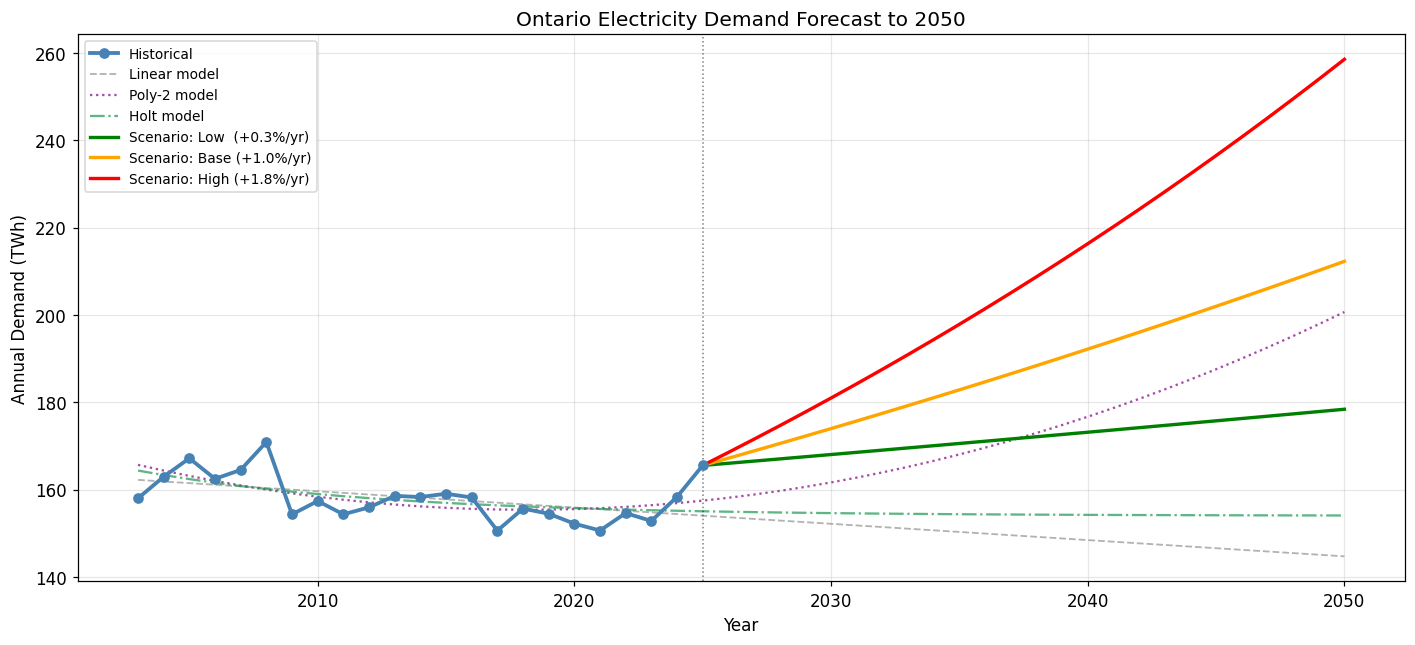

In [28]:
# Scenario forecasts anchored at 2025 actual value
# Growth rates reflect: low=efficiency gains, base=moderate electrification, high=aggressive EVs/heat-pumps/data-centres
base_2025 = df.loc[df['Year'] == 2025, 'TWh'].values[0]
future_years = np.arange(2025, 2051)

scenarios = {
    'Low  (+0.3%/yr)' : 0.003,
    'Base (+1.0%/yr)' : 0.010,
    'High (+1.8%/yr)' : 0.018,
}
colours = {'Low  (+0.3%/yr)': 'green', 'Base (+1.0%/yr)': 'orange', 'High (+1.8%/yr)': 'red'}

fig, ax = plt.subplots(figsize=(13, 6))

# Historical
ax.plot(df['Year'], df['TWh'], 'o-', color='steelblue', linewidth=2.5, label='Historical', zorder=5)

# Model forecasts (dashed, light)
ax.plot(all_years, lin_pred,   '--', color='gray',   alpha=0.6, linewidth=1.2, label='Linear model')
ax.plot(all_years, poly2_pred, ':',  color='purple',  alpha=0.7, linewidth=1.5, label='Poly-2 model')
ax.plot(all_years, holt_pred,  '-.', color='#1a9850', alpha=0.7, linewidth=1.5, label='Holt model')

# Scenario bands
for label, rate in scenarios.items():
    vals = base_2025 * (1 + rate) ** (future_years - 2025)
    ax.plot(future_years, vals, linewidth=2.2, color=colours[label], label=f'Scenario: {label}')

ax.axvline(2025, color='black', linestyle=':', alpha=0.5, linewidth=1)
ax.set(title='Ontario Electricity Demand Forecast to 2050',
       xlabel='Year', ylabel='Annual Demand (TWh)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [29]:
# Summary table: scenario values at key years
rows = []
for label, rate in scenarios.items():
    row = {'Scenario': label}
    for yr in [2030, 2035, 2040, 2045, 2050]:
        row[str(yr)] = round(base_2025 * (1 + rate) ** (yr - 2025), 1)
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Scenario')
print(f"\nBase year (2025): {base_2025:.1f} TWh\n")
print(summary.to_string())



Base year (2025): 165.5 TWh

                  2030   2035   2040   2045   2050
Scenario                                          
Low  (+0.3%/yr)  168.0  170.5  173.1  175.7  178.4
Base (+1.0%/yr)  174.0  182.8  192.2  202.0  212.3
High (+1.8%/yr)  181.0  197.8  216.3  236.5  258.5
